In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Simulate A/B data


Control conversion rate = 10%

Treatment conversion rate = 13%

1000 users each

In [2]:
np.random.seed(42)
n=1000
control = np.random.binomial(1, 0.1, n)
treatment = np.random.binomial(1, 0.13, n)

Compute basic stats

In [3]:
control_mean = control.mean()
treatment_mean = treatment.mean()

control_std = control.std()
treatment_std = treatment.std()

control_mean, treatment_mean

(0.1, 0.131)

Compute standard error

In [4]:
control_se = control_std/np.sqrt(n)
treatment_se = treatment_std/np.sqrt(n)

control_se, treatment_se

(0.009486832980505138, 0.010669536072388528)

Difference in means and pooled standard error

In [5]:
diff = treatment_mean - control_mean

pooled_se = np.sqrt((control_std**2/n) + (treatment_std**2/n))

diff, pooled_se

(0.031, 0.014277219617278429)

t-stat

In [6]:
t_stat = diff/pooled_se
t_stat

2.1712911078627313

p-value

In [7]:
p_value = 2*(1- stats.t.cdf(abs(t_stat), df = 2*n-2))
p_value

0.030026514757041767

In [9]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: Treatment effect is statistically significant.")
else:
    print("Fail to reject H0: No statistically significant difference.")


Reject H0: Treatment effect is statistically significant.


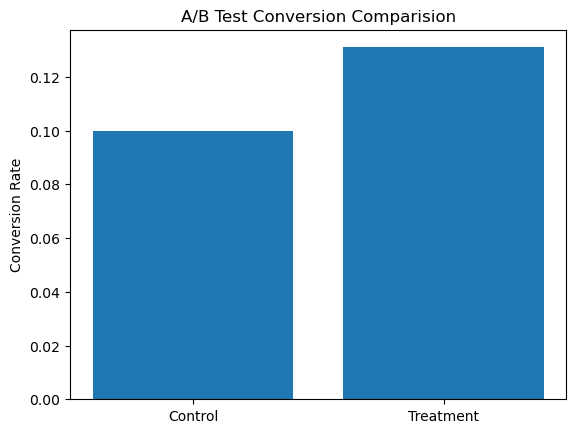

In [11]:
labels = ['Control', 'Treatment']
means = [control_mean, treatment_mean]

plt.bar(labels,means)
plt.ylabel('Conversion Rate')
plt.title('A/B Test Conversion Comparision')
plt.show()